In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.tree import plot_tree
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder

In [32]:
df= pd.read_csv("loan.csv")

In [33]:
df.sample(3)

,Applicant,Age,Income,Credit_Score,Loan_Approved
88,89,Young,High,Bad,No
235,236,Middle,High,Good,Yes
188,189,Old,High,Good,Yes


In [34]:
X= df.iloc[:, 1:4]
y= df.iloc[:,4]
print(X)
print("\n\n", y)

        Age  Income Credit_Score
0     Young    High         Good
1     Young    High          Bad
2    Middle    High          Bad
3       Old  Medium          Bad
4       Old     Low         Good
..      ...     ...          ...
305   Young    High         Good
306   Young     Low         Good
307     Old    High         Good
308   Young     Low          Bad
309  Middle    High          Bad

[310 rows x 3 columns]


 0      Yes
1       No
2      Yes
3      Yes
4       No
      ... 
305    Yes
306     No
307    Yes
308     No
309    Yes
Name: Loan_Approved, Length: 310, dtype: str


# Train Test Split

In [35]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state=42)

# Encoding Data

In [43]:
oe = OrdinalEncoder(categories=[['Young', 'Middle', 'Old'], ['Low', 'Medium', 'High'], ['Bad', 'Good']], dtype=np.int32)
X_train_new= oe.fit_transform(X_train)
X_test_new= oe.transform(X_test)
le= LabelEncoder()
y_train_new= le.fit_transform(y_train)
y_test_new= le.transform(y_test)

In [37]:
X_train_new = pd.DataFrame(X_train_new, columns=oe.get_feature_names_out())
X_test_new = pd.DataFrame(X_test_new, columns=oe.get_feature_names_out())

# ohe.get_feature_names_out() returns an array of column names based on the original feature names and their encoded values.
X_train_new.sample(5)

,Age,Income,Credit_Score
126,1,0,0
118,0,1,0
143,0,2,1
0,1,1,1
139,1,1,1


# Model Selection

In [38]:
model= DecisionTreeClassifier(random_state=42)
model.fit(X_train_new, y_train_new)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

# Predicted Values

In [39]:
y_pred= model.predict(X_test_new)
print(y_pred)
print("\n\n",y_test_new)

[0 1 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 1 0 1 1 1 1 1 1 0 1 1 0 0 0 1 1
 0 0 1 1 1 1 1 1 0 0 0 0 1 1 0 1 1 1 0 0 1 1 1 1 0]


 [0 1 0 1 1 1 1 0 0 0 0 1 0 1 1 0 0 1 1 1 1 1 0 0 1 1 0 1 1 0 1 1 0 0 0 1 1
 0 0 1 1 1 1 0 1 0 0 0 0 1 1 0 1 1 1 0 0 1 1 1 1 0]


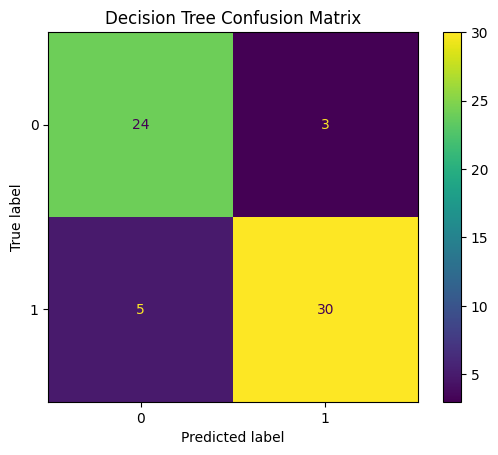

In [40]:
ConfusionMatrixDisplay.from_predictions(y_test_new, y_pred)
plt.title("Decision Tree Confusion Matrix")
plt.show()

# Classification Report

In [41]:
print(classification_report(y_test_new, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86        27
           1       0.91      0.86      0.88        35

    accuracy                           0.87        62
   macro avg       0.87      0.87      0.87        62
weighted avg       0.87      0.87      0.87        62



# Decision Tree Visualization

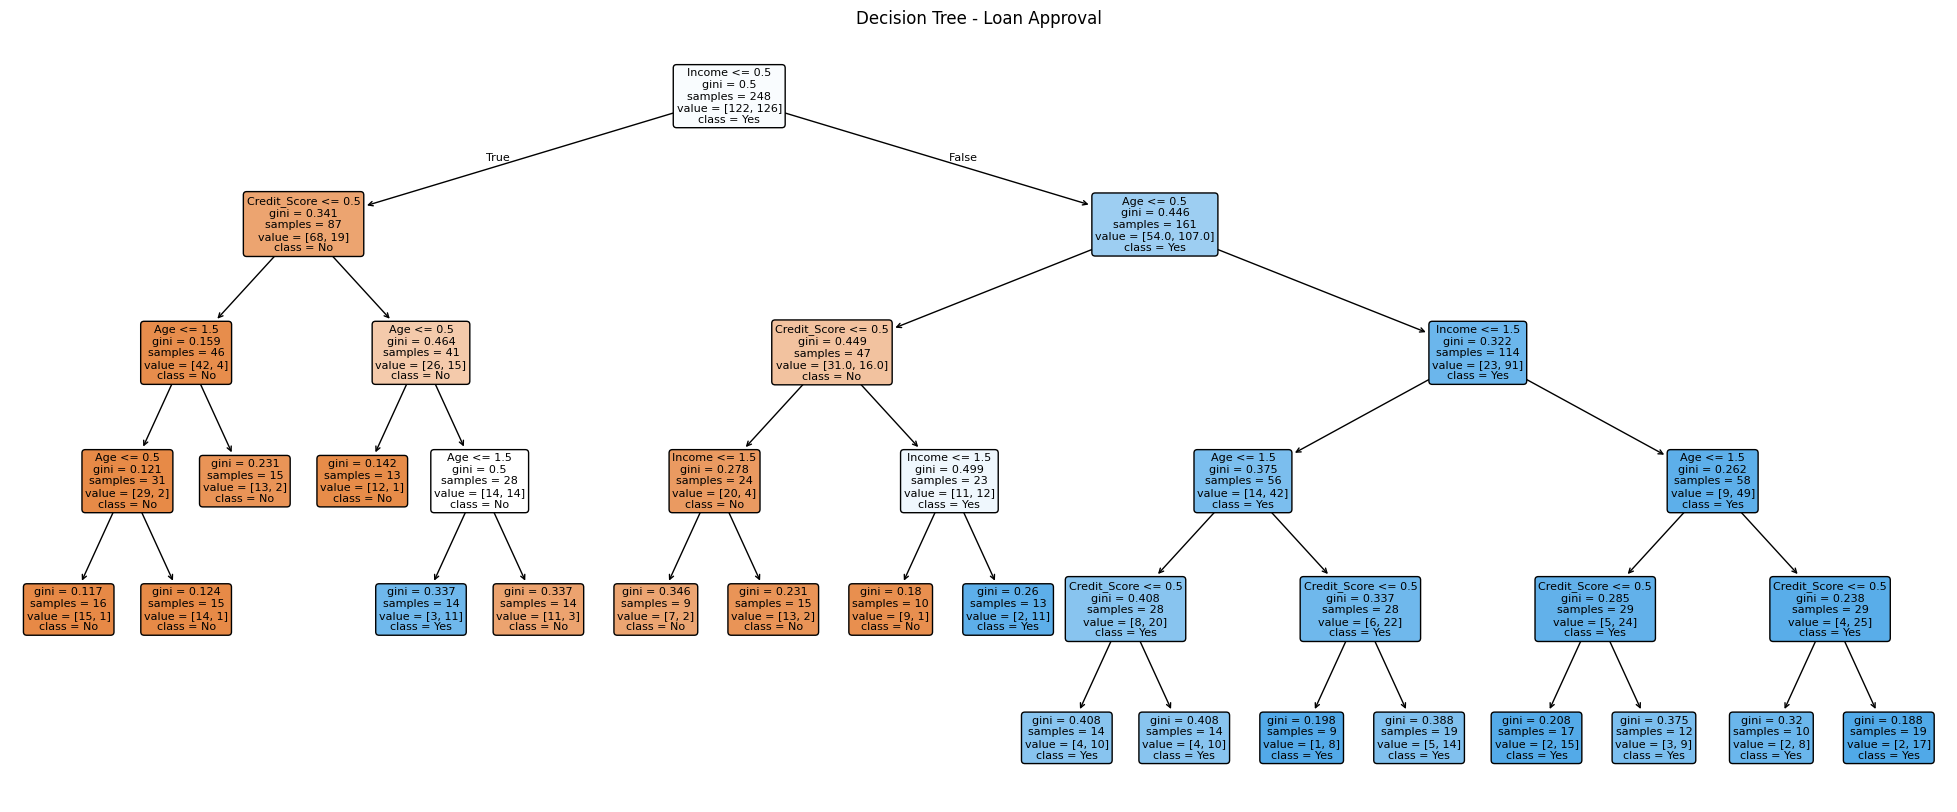

In [42]:
plt.figure(figsize=(25, 10))
plot_tree(model, 
          feature_names=oe.get_feature_names_out(), 
          class_names=le.classes_,
          filled=True, 
          rounded=True, 
          fontsize=8)
plt.title("Decision Tree - Loan Approval")
plt.show()